In [2]:
## load stuff and the target sequences from pkl
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values

with open(os.path.join(REPO, 'virtual_perturbations/diff_call/results/target_loci_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
target_df = target_lib['df'] if isinstance(target_lib, dict) and 'df' in target_lib else target_lib
target_idx = np.asarray(target_df['seq_idx'].values)
print(f'target seqs: {len(target_idx)}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
target seqs: 8


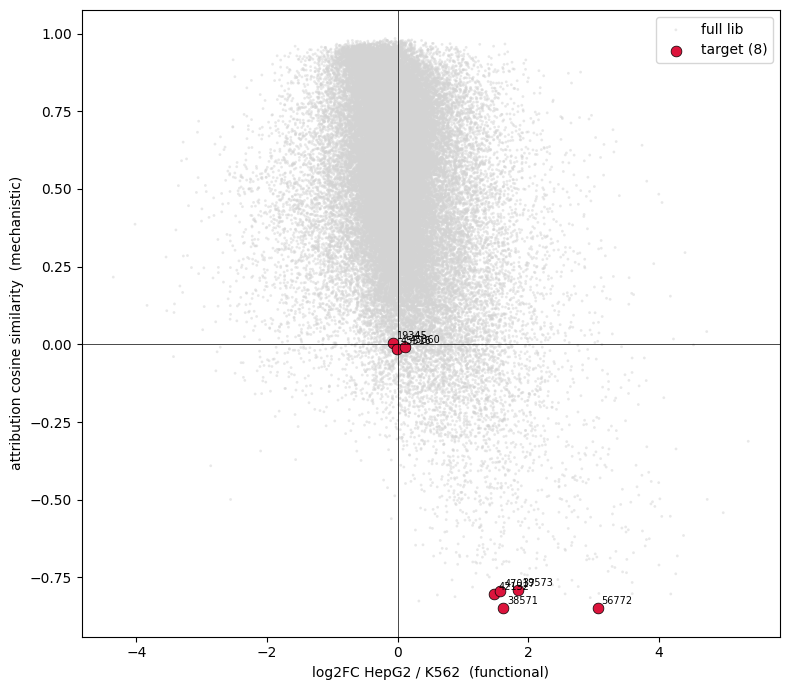

In [3]:
# show selected seqs on func,mech space
fin = np.isfinite(cossim) & np.isfinite(lfc)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(lfc[fin], cossim[fin], s=4, c='lightgray', alpha=0.5, edgecolors='none', label='full lib')
ax.scatter(lfc[target_idx], cossim[target_idx], s=60, c='crimson', edgecolors='black', linewidths=0.5, label=f'target ({len(target_idx)})')
for s in target_idx:
    ax.annotate(str(s), (lfc[s], cossim[s]), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.axhline(0, c='k', lw=0.5); ax.axvline(0, c='k', lw=0.5)
ax.set_xlabel('log2FC HepG2 / K562  (functional)')
ax.set_ylabel('attribution cosine similarity  (mechanistic)')
ax.legend()
plt.tight_layout()

FG: 8/8 | BG: 8/8


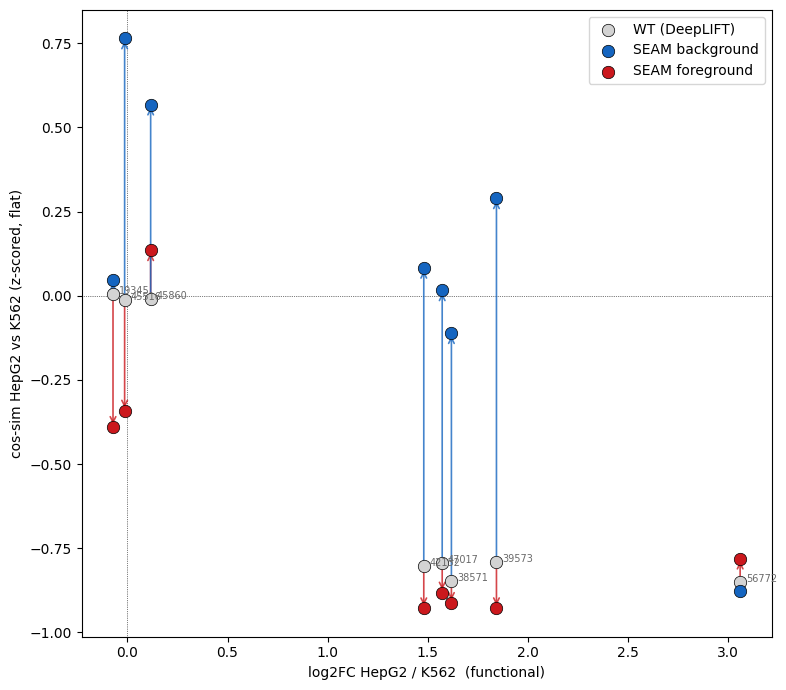

In [4]:
# targets only on func/mech space: WT (gray) -> SEAM foreground (red) and SEAM background (blue)
FG_DIR = os.path.join(REPO, 'SEAM_target_spaces', 'results', 'foregrounds')

def _zflat(a):
    a = a.astype(np.float64).ravel()
    s = a.std()
    return (a - a.mean()) / s if s > 0 else a - a.mean()

def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else np.nan

cos_fg = np.full(len(target_idx), np.nan)
cos_bg = np.full(len(target_idx), np.nan)
for i, sid in enumerate(target_idx):
    try:
        fH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/foreground_scaled.npy'))
        fK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/foreground_scaled.npy'))
        bH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/average_background_scaled.npy'))
        bK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/average_background_scaled.npy'))
        cos_fg[i] = _cos(fH, fK)
        cos_bg[i] = _cos(bH, bK)
    except FileNotFoundError:
        pass
print(f'FG: {np.isfinite(cos_fg).sum()}/{len(target_idx)} | BG: {np.isfinite(cos_bg).sum()}/{len(target_idx)}')

x = lfc[target_idx]
cos_wt = cossim[target_idx]

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(len(target_idx)):
    ax.annotate('', xy=(x[i], cos_fg[i]), xytext=(x[i], cos_wt[i]),
                arrowprops=dict(arrowstyle='->', color='#cb181d', lw=1.2, alpha=0.8))
    ax.annotate('', xy=(x[i], cos_bg[i]), xytext=(x[i], cos_wt[i]),
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.2, alpha=0.8))
ax.scatter(x, cos_wt, s=80, c='lightgray', edgecolors='black', linewidths=0.5, label='WT (DeepLIFT)', zorder=3)
ax.scatter(x, cos_bg, s=80, c='#1565C0',   edgecolors='black', linewidths=0.5, label='SEAM background', zorder=3)
ax.scatter(x, cos_fg, s=80, c='#cb181d',   edgecolors='black', linewidths=0.5, label='SEAM foreground', zorder=3)
for i, sid in enumerate(target_idx):
    ax.annotate(str(sid), (x[i], cos_wt[i]), fontsize=7, xytext=(4, 0), textcoords='offset points', color='dimgray')
ax.axhline(0, c='k', lw=0.5, ls=':'); ax.axvline(0, c='k', lw=0.5, ls=':')
ax.set_xlabel('log2FC HepG2 / K562  (functional)')
ax.set_ylabel('cos-sim HepG2 vs K562 (z-scored, flat)')
ax.legend()
plt.tight_layout()

FG: 1059/1059 | BG: 1059/1059


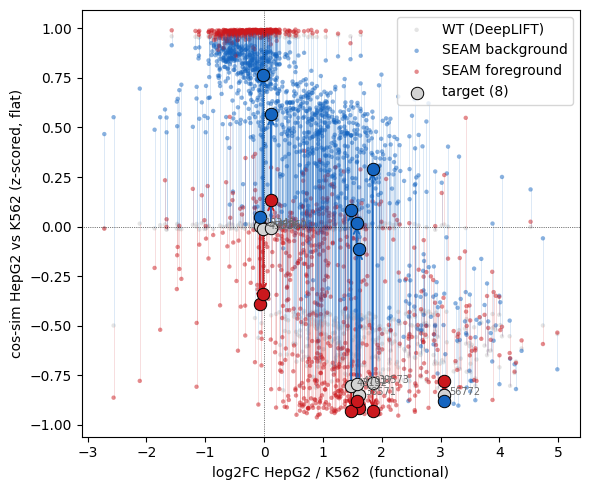

In [24]:
# same WT / FG / BG layers as above, but for every seq with a SEAM run (1059)
all_idx = np.array(sorted(int(d) for d in os.listdir(f'{FG_DIR}/HepG2')))
cos_fg_all = np.full(len(all_idx), np.nan)
cos_bg_all = np.full(len(all_idx), np.nan)
for i, sid in enumerate(all_idx):
    try:
        fH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/foreground_scaled.npy'))
        fK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/foreground_scaled.npy'))
        bH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/average_background_scaled.npy'))
        bK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/average_background_scaled.npy'))
        cos_fg_all[i] = _cos(fH, fK)
        cos_bg_all[i] = _cos(bH, bK)
    except FileNotFoundError:
        pass
print(f'FG: {np.isfinite(cos_fg_all).sum()}/{len(all_idx)} | BG: {np.isfinite(cos_bg_all).sum()}/{len(all_idx)}')

x = lfc[all_idx]
cos_wt_all = cossim[all_idx]
is_target = np.isin(all_idx, target_idx)

fig, ax = plt.subplots(figsize=(6, 5))
# WT -> FG (red) and WT -> BG (blue) segments per seq, thin and translucent for 1059 pts
seg_fg = np.stack([np.column_stack([x, cos_wt_all]), np.column_stack([x, cos_fg_all])], axis=1)
seg_bg = np.stack([np.column_stack([x, cos_wt_all]), np.column_stack([x, cos_bg_all])], axis=1)
from matplotlib.collections import LineCollection
ax.add_collection(LineCollection(seg_fg, colors='#cb181d', linewidths=0.4, alpha=0.25))
ax.add_collection(LineCollection(seg_bg, colors='#1565C0', linewidths=0.4, alpha=0.25))
ax.scatter(x, cos_wt_all, s=10, c='lightgray', alpha=0.6, edgecolors='none', label='WT (DeepLIFT)')
ax.scatter(x, cos_bg_all, s=10, c='#1565C0',   alpha=0.5, edgecolors='none', label='SEAM background')
ax.scatter(x, cos_fg_all, s=10, c='#cb181d',   alpha=0.5, edgecolors='none', label='SEAM foreground')

# highlight target seqs: bold WT/FG/BG markers + WT->FG, WT->BG arrows + sid labels
xt, wt_t, fg_t, bg_t = x[is_target], cos_wt_all[is_target], cos_fg_all[is_target], cos_bg_all[is_target]
for i in range(is_target.sum()):
    ax.annotate('', xy=(xt[i], fg_t[i]), xytext=(xt[i], wt_t[i]),
                arrowprops=dict(arrowstyle='->', color='#cb181d', lw=1.4, alpha=0.95), zorder=4)
    ax.annotate('', xy=(xt[i], bg_t[i]), xytext=(xt[i], wt_t[i]),
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.4, alpha=0.95), zorder=4)
ax.scatter(xt, wt_t, s=80, c='lightgray', edgecolors='black', linewidths=0.7, zorder=5, label=f'target ({is_target.sum()})')
ax.scatter(xt, bg_t, s=80, c='#1565C0',   edgecolors='black', linewidths=0.7, zorder=5)
ax.scatter(xt, fg_t, s=80, c='#cb181d',   edgecolors='black', linewidths=0.7, zorder=5)
for sid, xi, yi in zip(all_idx[is_target], xt, wt_t):
    ax.annotate(str(sid), (xi, yi), fontsize=7, xytext=(4, 0), textcoords='offset points', color='dimgray', zorder=6)

ax.axhline(0, c='k', lw=0.5, ls=':'); ax.axvline(0, c='k', lw=0.5, ls=':')
ax.set_xlabel('log2FC HepG2 / K562  (functional)')
ax.set_ylabel('cos-sim HepG2 vs K562 (z-scored, flat)')
ax.legend()
plt.tight_layout()

In [6]:
# precomputed finemo hits → motif_hits[ct] (skip denovo TF-MoDISco)
HITS_DIR = os.path.join(REPO, 'genomic_targets/data/motif')
hits_df = {ct: pd.read_csv(f'{HITS_DIR}/{ct}/hits.tsv', sep='\t',
                           usecols=['start', 'end', 'motif_name',
                                    'hit_correlation', 'peak_name'])
           for ct in ('HepG2', 'K562')}

def _finemo_hits_for(em_s, sid):
    name = df.iloc[sid]['name']
    em_s.motif_hits = {}
    for ct, hdf in hits_df.items():
        sub = hdf[hdf['peak_name'] == name]
        em_s.motif_hits[ct] = [[
            {'start': int(r.start), 'end': int(r.end),
             'tf': r.motif_name.replace('pos_patterns.pattern_', 'p')
                              .replace('neg_patterns.pattern_', 'n'),
             'pval': float(r.hit_correlation),
             'top_hits': [{'tf': r.motif_name, 'pval': float(r.hit_correlation)}]}
            for r in sub.itertuples()
        ]]
    return em_s

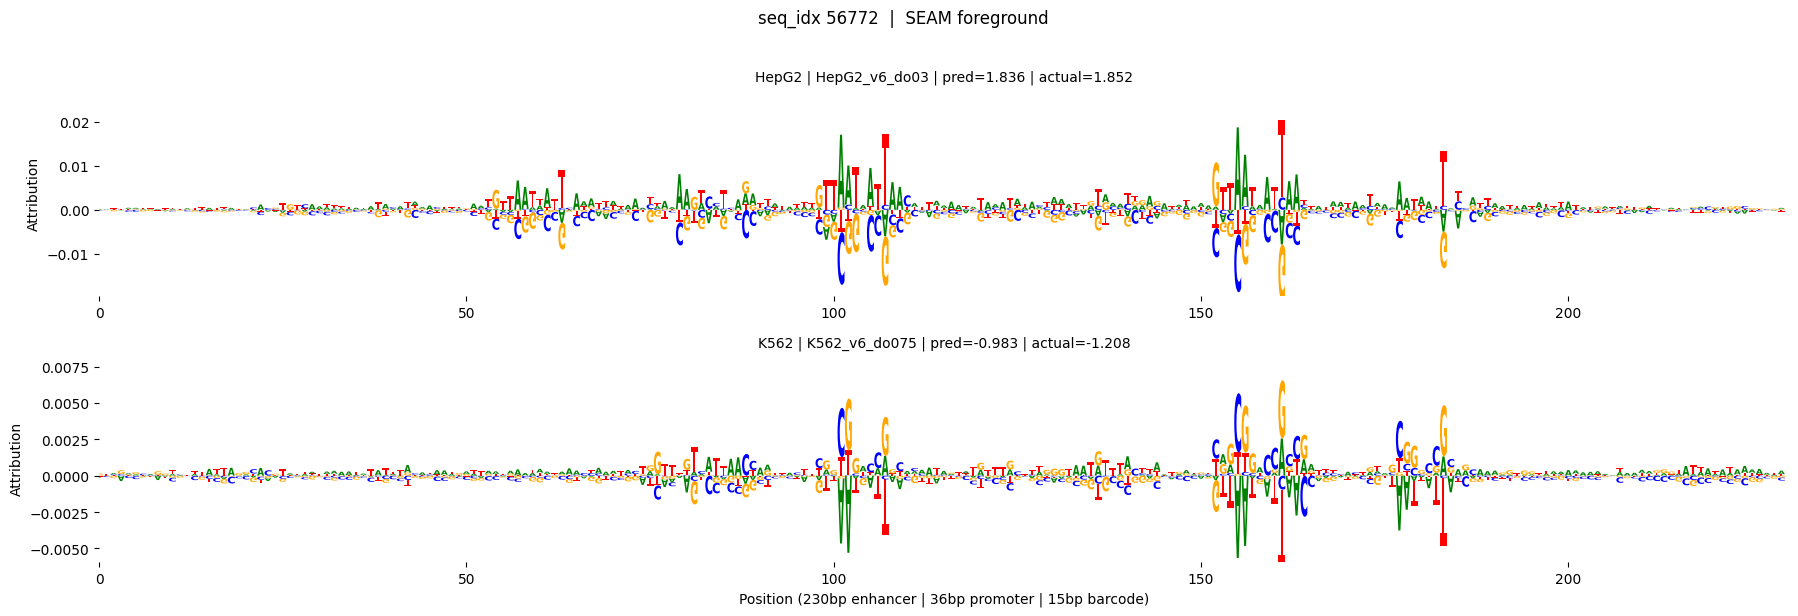

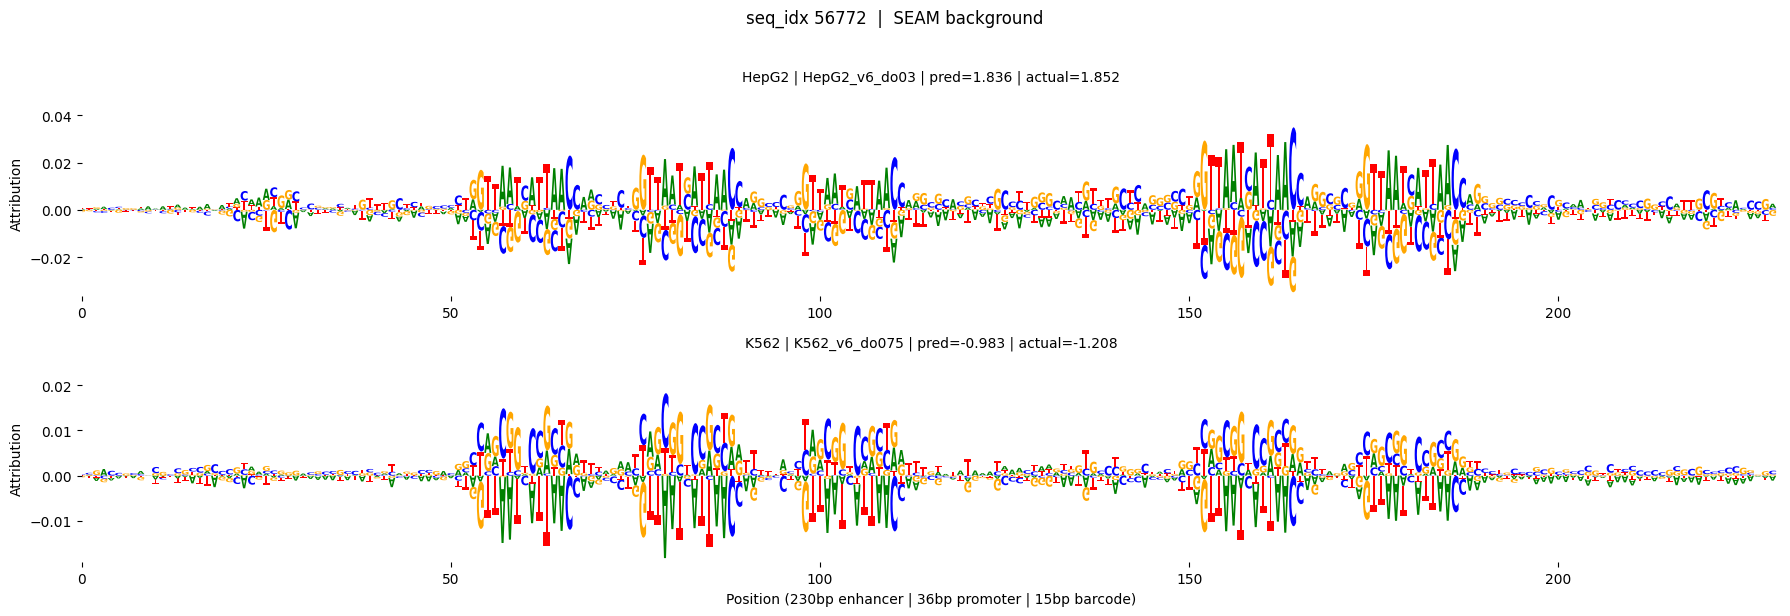

In [35]:
# pick a target seq, view SEAM foreground vs background logos with finemo motif annotations
import copy
SID = 56772                                  # <-- change me
s = int(SID)
ENH = 230                                     # enhancer-only — promoter+barcode dropped from visualization

def _seam_em(kind, project_ohe=False):
    em_s = copy.copy(em)
    em_s.cell_types = ['HepG2', 'K562']
    em_s.X = em.X[s:s+1]
    em_s.constructs = [em.constructs[s]]
    ohe_4L = em.X[s].numpy()                  # (4, 281)
    fname = 'foreground_scaled.npy' if kind == 'fg' else 'average_background_scaled.npy'
    em_s.attr, em_s.attr_hyp, em_s.importance, em_s.predictions, em_s.actual = {}, {}, {}, {}, {}
    for ct in ('HepG2', 'K562'):
        a = np.load(f'{FG_DIR}/{ct}/{SID}/{fname}')
        if a.shape[-1] != 4: a = a.T          # (L, 4)
        attr_4L = np.zeros_like(ohe_4L)
        attr_4L[:, :ENH] = a.T                # SEAM enhancer attr; tail stays zero
        if project_ohe:
            attr_4L = attr_4L * ohe_4L
        em_s.attr[ct]       = attr_4L[None]   # (1, 4, 281)
        em_s.attr_hyp[ct]   = attr_4L[None]
        em_s.importance[ct] = attr_4L.sum(0)[None]
        em_s.predictions[ct] = np.array([em.predictions[ct][s]])
        if ct in em.actual and em.actual[ct] is not None:
            em_s.actual[ct] = np.array([em.actual[ct][s]])
    return em_s

def _draw_seam_logos(em_s, suptitle):
    fig, axes = em_s.plot_attr_logos(seq_idx=0)              # baseline panels
    for ci, ct in enumerate(('HepG2', 'K562')):              # native per-panel y-scale
        ax = axes[ci]
        for p in list(ax.patches): p.remove()                # nuke promoter/barcode axvspans from plot_attr_logos
        a = em_s.attr[ct][0][:, :ENH]
        ymax = float(np.abs(a).max()) * 1.05 or 1.0
        ax.set_ylim(-ymax, ymax * 1.4)                       # headroom for motif labels
        for h in em_s.motif_hits[ct][0]:
            mid = (h['start'] + h['end']) / 2
        ax.set_xlim(0, ENH); ax.autoscale(False)             # enhancer only, lock it
        for sp in ax.spines.values():                        # strip box borders
            sp.set_visible(False)
    fig.suptitle(suptitle, fontsize=12, y=1.02)
    plt.tight_layout()
    return fig, axes

for kind, label in (('fg', 'SEAM foreground'), ('bg', 'SEAM background')):
    em_s = _seam_em(kind)
    _finemo_hits_for(em_s, s)
    _draw_seam_logos(em_s, f'seq_idx {SID}  |  {label}')

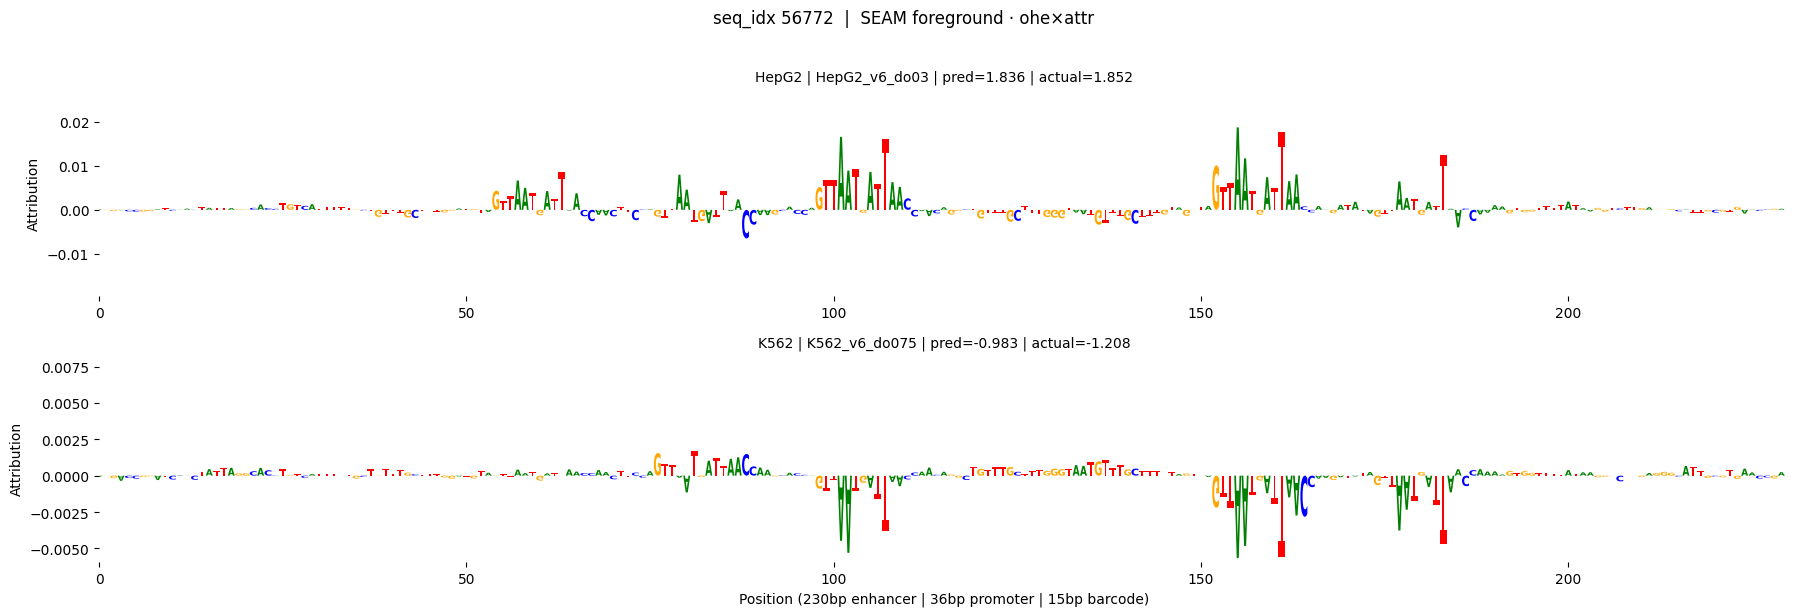

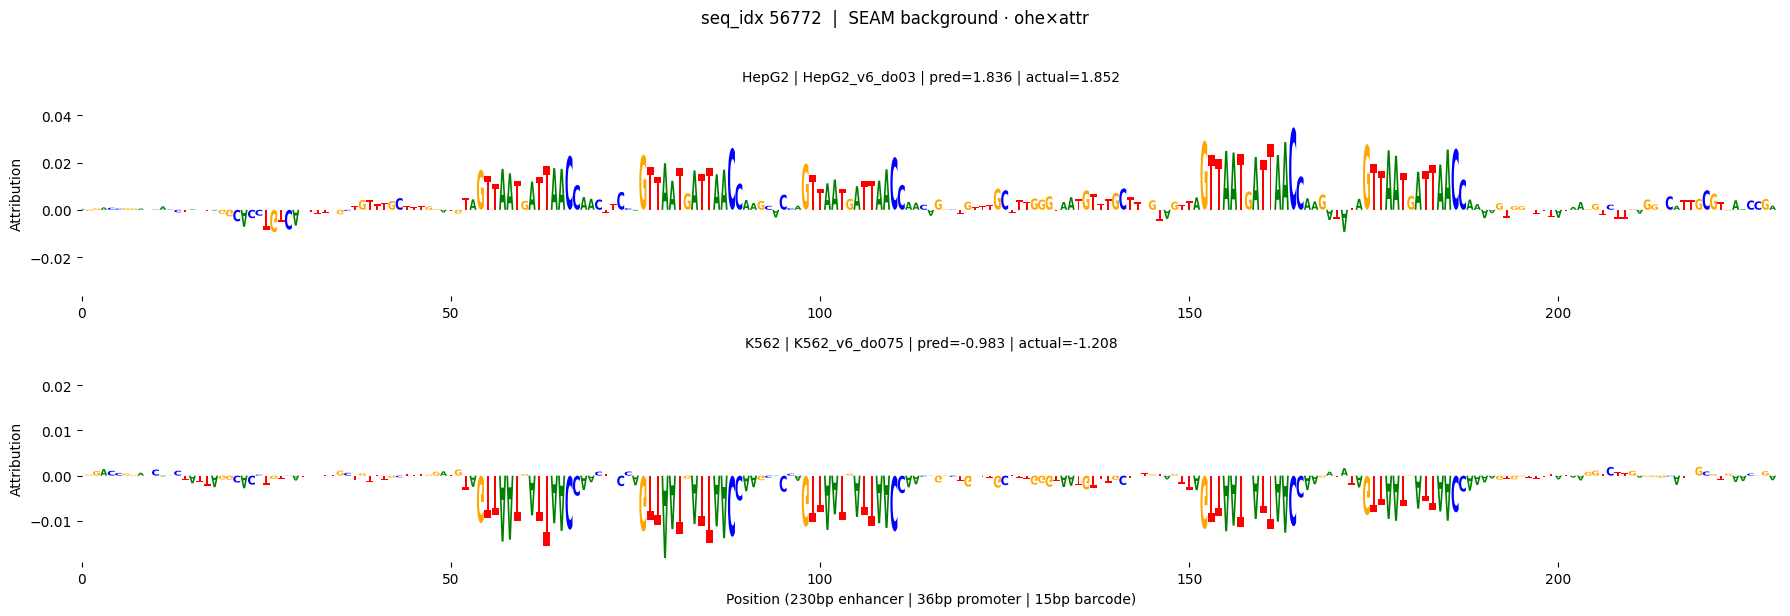

In [36]:
# same plots but ohe * attr (projected to actual base) — uses helpers from cell above
for kind, label in (('fg', 'SEAM foreground · ohe×attr'), ('bg', 'SEAM background · ohe×attr')):
    em_s = _seam_em(kind, project_ohe=True)
    _finemo_hits_for(em_s, s)
    _draw_seam_logos(em_s, f'seq_idx {SID}  |  {label}')

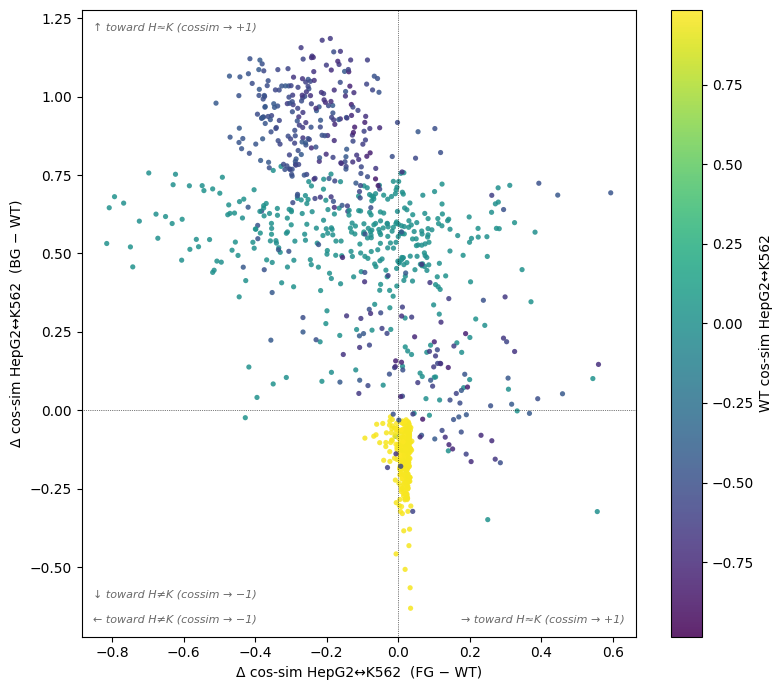

In [37]:
# each point = one WT, colored by its HepG2↔K562 cossim (mech similarity between cell lines).
# axes = change in that between-cell-line cossim under SEAM FG / BG perturbation.
dfg = cos_fg_all - cos_wt_all
dbg = cos_bg_all - cos_wt_all
fin = np.isfinite(dfg) & np.isfinite(dbg) & np.isfinite(cos_wt_all)
v = np.nanmax(np.abs(cos_wt_all[fin]))

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(dfg[fin], dbg[fin], c=cos_wt_all[fin], cmap='viridis', vmin=-v, vmax=v,
                s=14, alpha=0.85, edgecolors='none')
ax.axhline(0, c='k', lw=0.5, ls=':'); ax.axvline(0, c='k', lw=0.5, ls=':')
ax.set_xlabel('Δ cos-sim HepG2↔K562  (FG − WT)')
ax.set_ylabel('Δ cos-sim HepG2↔K562  (BG − WT)')

# direction cues: +Δ → toward H↔K cossim = +1 (more similar);  −Δ → toward −1 (more dissimilar)
ax.annotate('→ toward H≈K (cossim → +1)', xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='dimgray', style='italic')
ax.annotate('← toward H≠K (cossim → −1)', xy=(0.02, 0.02), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=8, color='dimgray', style='italic')
ax.annotate('↑ toward H≈K (cossim → +1)', xy=(0.02, 0.98), xycoords='axes fraction',
            ha='left', va='top', fontsize=8, color='dimgray', style='italic')
ax.annotate('↓ toward H≠K (cossim → −1)', xy=(0.02, 0.06), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=8, color='dimgray', style='italic')

plt.colorbar(sc, ax=ax, label='WT cos-sim HepG2↔K562')
plt.tight_layout()

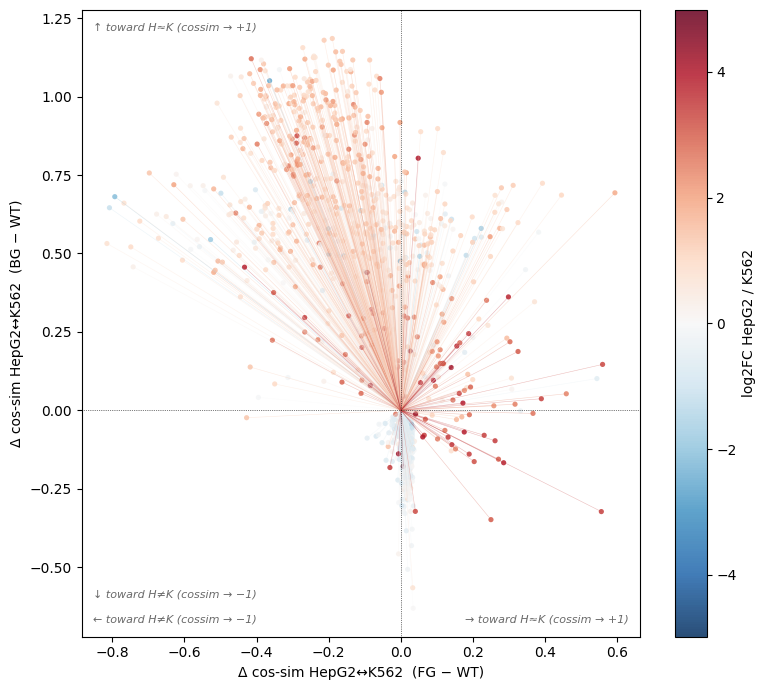

In [10]:
# same axes, color = log2FC HepG2 / K562 (red=HepG2, blue=K562). arrows: each point as a vector from (0,0).
c = lfc[all_idx]
fin = np.isfinite(dfg) & np.isfinite(dbg) & np.isfinite(c)
v = np.nanmax(np.abs(c[fin]))

fig, ax = plt.subplots(figsize=(8, 7))
# vectors from origin to (dfg, dbg), colored by lfc to match points
from matplotlib.collections import LineCollection
seg = np.stack([np.zeros((fin.sum(), 2)), np.column_stack([dfg[fin], dbg[fin]])], axis=1)
lc = LineCollection(seg, array=c[fin], cmap='RdBu_r', linewidths=0.4, alpha=0.35)
lc.set_clim(-v, v)
ax.add_collection(lc)
sc = ax.scatter(dfg[fin], dbg[fin], c=c[fin], cmap='RdBu_r', vmin=-v, vmax=v,
                s=14, alpha=0.85, edgecolors='none')
ax.axhline(0, c='k', lw=0.5, ls=':'); ax.axvline(0, c='k', lw=0.5, ls=':')
ax.set_xlabel('Δ cos-sim HepG2↔K562  (FG − WT)')
ax.set_ylabel('Δ cos-sim HepG2↔K562  (BG − WT)')

# direction cues: +Δ → toward H↔K cossim = +1 (more similar);  −Δ → toward −1 (more dissimilar)
ax.annotate('→ toward H≈K (cossim → +1)', xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='dimgray', style='italic')
ax.annotate('← toward H≠K (cossim → −1)', xy=(0.02, 0.02), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=8, color='dimgray', style='italic')
ax.annotate('↑ toward H≈K (cossim → +1)', xy=(0.02, 0.98), xycoords='axes fraction',
            ha='left', va='top', fontsize=8, color='dimgray', style='italic')
ax.annotate('↓ toward H≠K (cossim → −1)', xy=(0.02, 0.06), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=8, color='dimgray', style='italic')

plt.colorbar(sc, ax=ax, label='log2FC HepG2 / K562')
plt.tight_layout()

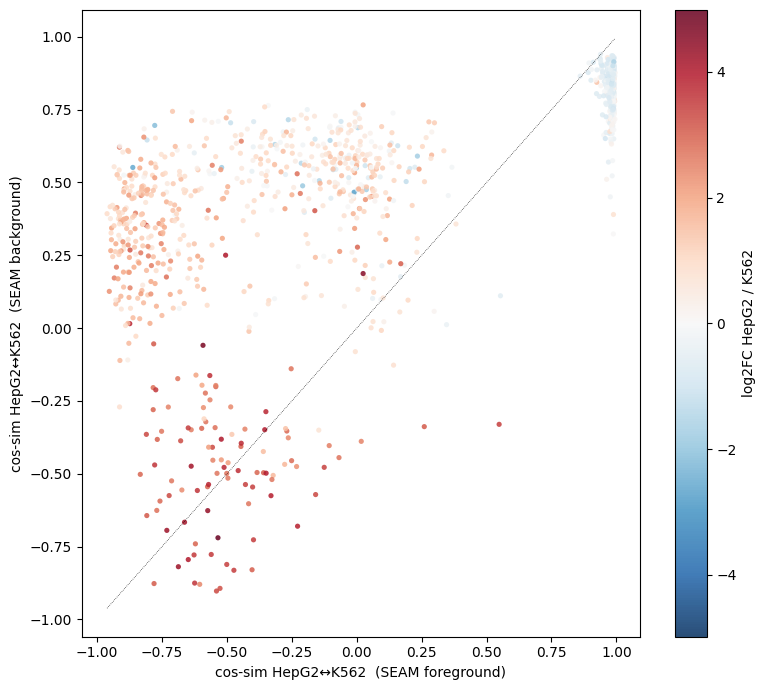

In [11]:
# raw H↔K cossim space: x = FG cossim, y = BG cossim. color = log2FC HepG2 / K562.
c = lfc[all_idx]
fin = np.isfinite(cos_fg_all) & np.isfinite(cos_bg_all) & np.isfinite(c)
v = np.nanmax(np.abs(c[fin]))

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(cos_fg_all[fin], cos_bg_all[fin], c=c[fin], cmap='RdBu_r', vmin=-v, vmax=v,
                s=14, alpha=0.85, edgecolors='none')
lo = min(np.nanmin(cos_fg_all[fin]), np.nanmin(cos_bg_all[fin]))
hi = max(np.nanmax(cos_fg_all[fin]), np.nanmax(cos_bg_all[fin]))
ax.plot([lo, hi], [lo, hi], 'k:', lw=0.5)
ax.set_xlabel('cos-sim HepG2↔K562  (SEAM foreground)')
ax.set_ylabel('cos-sim HepG2↔K562  (SEAM background)')
plt.colorbar(sc, ax=ax, label='log2FC HepG2 / K562')
plt.tight_layout()

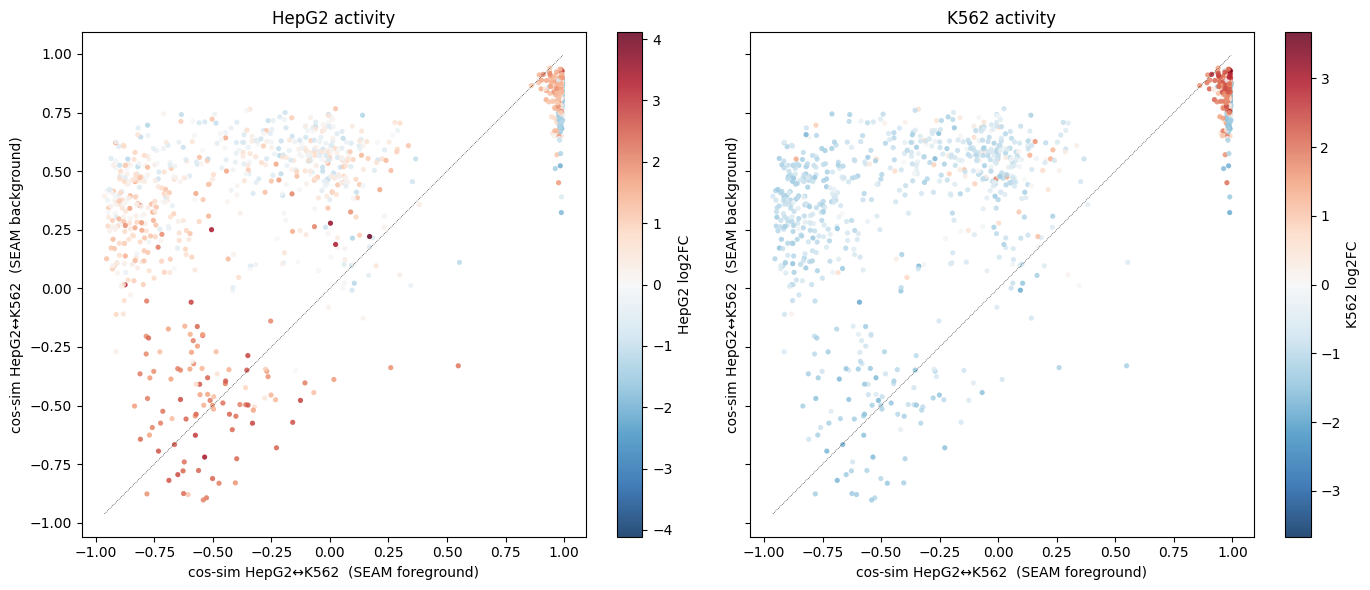

In [12]:
# same FG vs BG H↔K cossim space, but color = single-cell-line activity (log2FC). one panel per cell line.
act = {ct: df[f'{ct}_log2FC'].values[all_idx] for ct in ('HepG2', 'K562')}
fin = np.isfinite(cos_fg_all) & np.isfinite(cos_bg_all)
lo = min(np.nanmin(cos_fg_all[fin]), np.nanmin(cos_bg_all[fin]))
hi = max(np.nanmax(cos_fg_all[fin]), np.nanmax(cos_bg_all[fin]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, ct in zip(axes, ('HepG2', 'K562')):
    a = act[ct]
    m = fin & np.isfinite(a)
    v = np.nanmax(np.abs(a[m]))
    sc = ax.scatter(cos_fg_all[m], cos_bg_all[m], c=a[m], cmap='RdBu_r', vmin=-v, vmax=v,
                    s=14, alpha=0.85, edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'k:', lw=0.5)
    ax.set_xlabel('cos-sim HepG2↔K562  (SEAM foreground)')
    ax.set_ylabel('cos-sim HepG2↔K562  (SEAM background)')
    ax.set_title(f'{ct} activity')
    plt.colorbar(sc, ax=ax, label=f'{ct} log2FC')
plt.tight_layout()

sid 56774  |  name=C:SLEA_hg18:chr2:210861483-210861650|7:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;33:V_HNF4_Q6:AAGGTCCAG;45:V_HNF1_C:AGTTAATGATTAACCAA;65:V_HNF3ALPHA_Q6:TGTTTGCTTTG;79:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;101:V_PPARA_02:CCGGGTCATTGGGGTCAGG;123:V_Rxra_UP:GGCCGTGACCCCGTGAT;143:V_XBP1_01:GTGATGACGTGTCCCAT  |  log2FC HepG2/K562=3.428
cos_wt=-0.008  cos_fg=0.548  cos_bg=-0.331


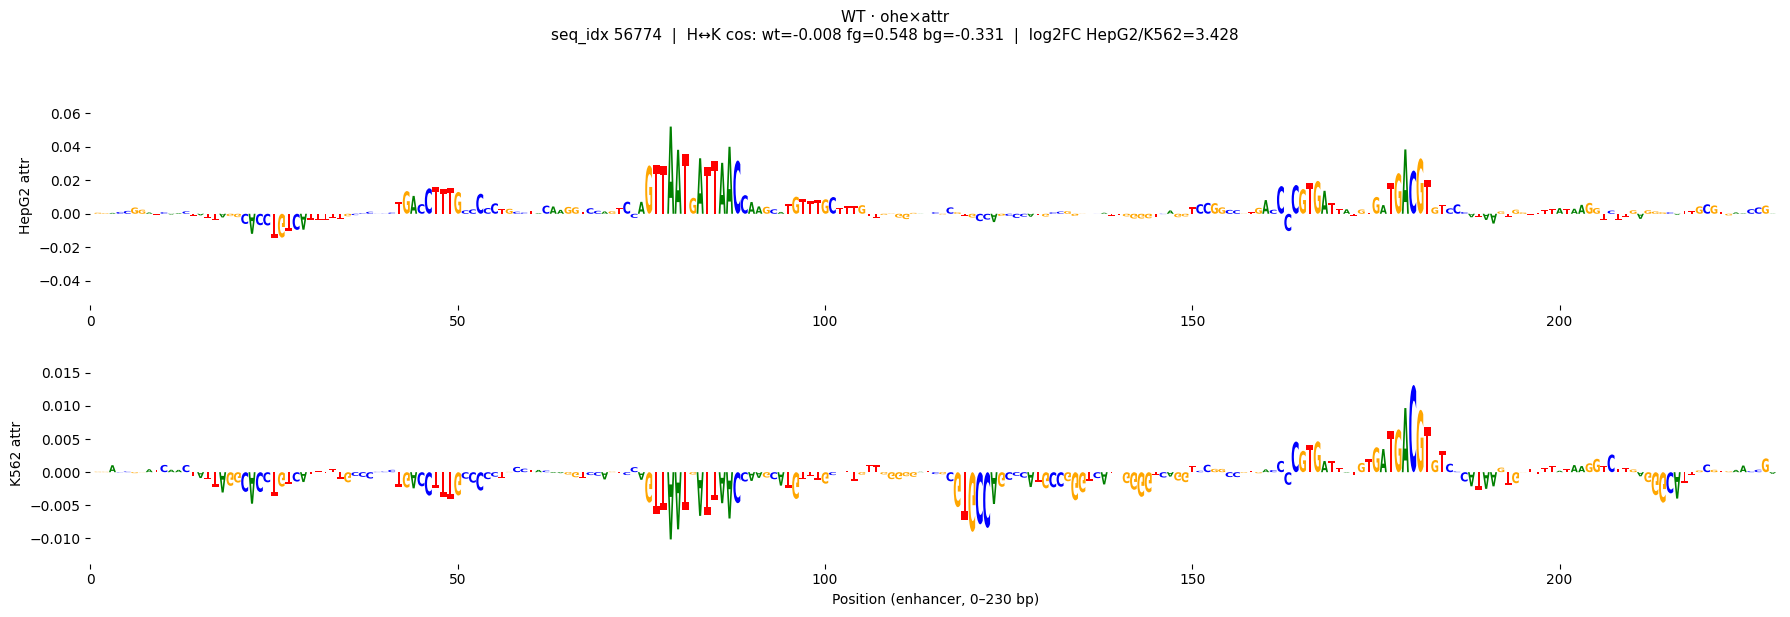

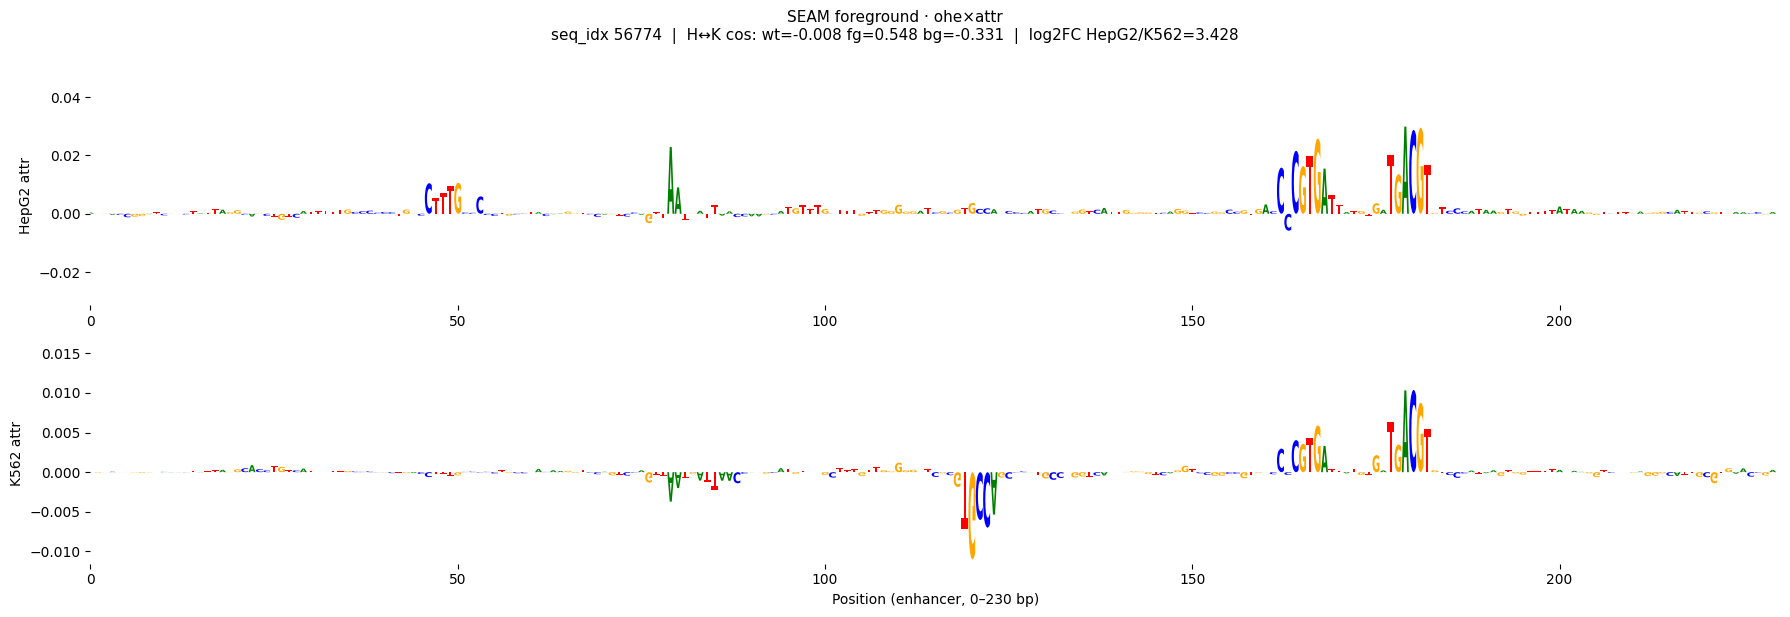

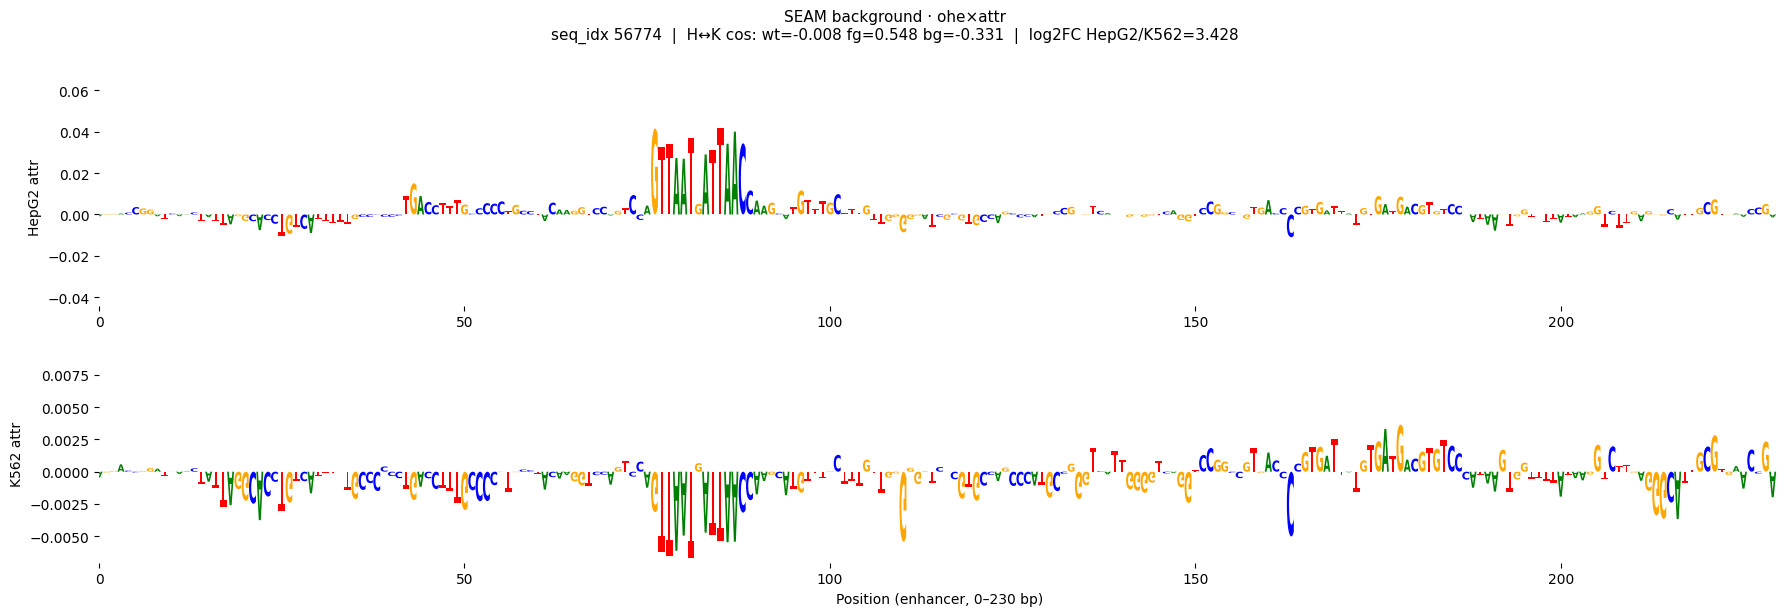

In [44]:
# pick a target by EITHER (a) a seq_idx directly, or (b) closest seq to a target point in (FG cossim, BG cossim) H↔K space.
# bypass plot_attr_logos entirely — call fast_logo directly so prom+barcode axvspans never get drawn.
from fast_logo import fast_logo as _fl

SID_OVERRIDE = None        # set to an int (any seq_idx with a SEAM run) to skip the fg/bg lookup
fg_sim = 1
bg_sim = -1

if SID_OVERRIDE is not None:
    SID = int(SID_OVERRIDE)
    assert SID in all_idx, f'seq_idx {SID} has no SEAM run under {FG_DIR}'
else:
    m = np.isfinite(cos_fg_all) & np.isfinite(cos_bg_all)
    d = (cos_fg_all - fg_sim)**2 + (cos_bg_all - bg_sim)**2
    d[~m] = np.inf
    SID = int(all_idx[np.argmin(d)])
s = SID
ai = np.where(all_idx == SID)[0][0]
cwt, cfg, cbg = float(cossim[SID]), float(cos_fg_all[ai]), float(cos_bg_all[ai])
row = df.iloc[SID]
lfc_sid = float(lfc[SID])                                 # log2FC HepG2 / K562 (same scalar used as x-axis upstream)
print(f'sid {SID}  |  name={row["name"]}  |  log2FC HepG2/K562={lfc_sid:.3f}')
print(f'cos_wt={cwt:.3f}  cos_fg={cfg:.3f}  cos_bg={cbg:.3f}')

# every panel gets the full context: H↔K cos for WT/FG/BG + the HepG2/K562 log2FC.
COMMON = (f'seq_idx {SID}  |  H↔K cos: wt={cwt:.3f} fg={cfg:.3f} bg={cbg:.3f}  '
          f'|  log2FC HepG2/K562={lfc_sid:.3f}')

def _enh_logos(attr, hits, head):
    fig, axes = plt.subplots(2, 1, figsize=(18, 6))
    for ax, ct in zip(axes, ('HepG2', 'K562')):
        a = attr[ct][:, :ENH]                                 # (4, ENH), enhancer-only
        ymax = float(np.abs(a).max()) * 1.05 or 1.0
        _fl(a, ax=ax, ylim=(-ymax, ymax * 1.4))
        if hits is not None:
            for h in hits[ct]:
                if h['start'] >= ENH: continue
                mid = (h['start'] + h['end']) / 2
        ax.set_xlim(0, ENH); ax.autoscale(False)
        ax.set_ylabel(f'{ct} attr')
        for sp in ax.spines.values(): sp.set_visible(False)
    axes[-1].set_xlabel('Position (enhancer, 0–230 bp)')
    fig.suptitle(f'{head}\n{COMMON}', fontsize=11, y=1.02)
    plt.tight_layout()
    return fig

_enh_logos({ct: em.attr[ct][SID] for ct in ('HepG2', 'K562')}, None,
           'WT · ohe×attr')

for kind, label in (('fg', 'SEAM foreground'), ('bg', 'SEAM background')):
    em_s = _seam_em(kind, project_ohe=True)
    _finemo_hits_for(em_s, SID)
    _enh_logos({ct: em_s.attr[ct][0] for ct in ('HepG2', 'K562')},
               {ct: em_s.motif_hits[ct][0] for ct in ('HepG2', 'K562')},
               f'{label} · ohe×attr')